In [1]:
import logging
from trails import Trails, lca, get_lcia_method_names, plot_temporal_scores
from datapackage import Package
from trails.logging import configure_trails_logging, trails_log_context

configure_trails_logging(file_level=logging.DEBUG)

dp = Package("datapackage.json")
#dp = Package("/Users/romain/GitHub/premise/dev/trails_2025-12-30.zip")
trails = Trails(dp, interpolate_annual=True, debug=True)

#methods = ["IPCC 2021 - climate change: fossil - global warming potential (GWP100)",]
methods = ["IPCC 2021 (incl. biogenic CO2) - climate change: total (incl. biogenic CO2) - global warming potential (GWP100)",]

Loaded interpolated matrices from cache: /Users/romain/Library/Application Support/trails/cache/interp_592d90d85ab3ba07ecc1471b0d8adddb69a0cb5531d0d21f24324d06f991dc27


In [2]:
from trails.plotting import plot_temporal_graph

trails.temporal_routing(
  start_year=2050,
  start_act_idx=13,
  amount=1.0,
  max_depth=3,
  show_progress=True,
  attribute_to_roots=True,
)

trails.lca(
    methods=methods,
    show_progress=True,
    compute_score=True,
    store_inventory=True,
)

Temporal routing: 1259node [00:01, 1037.52node/s]
Temporal LCA: solve years: 100%|█████████████| 41/41 [00:00<00:00, 413.90year/s]


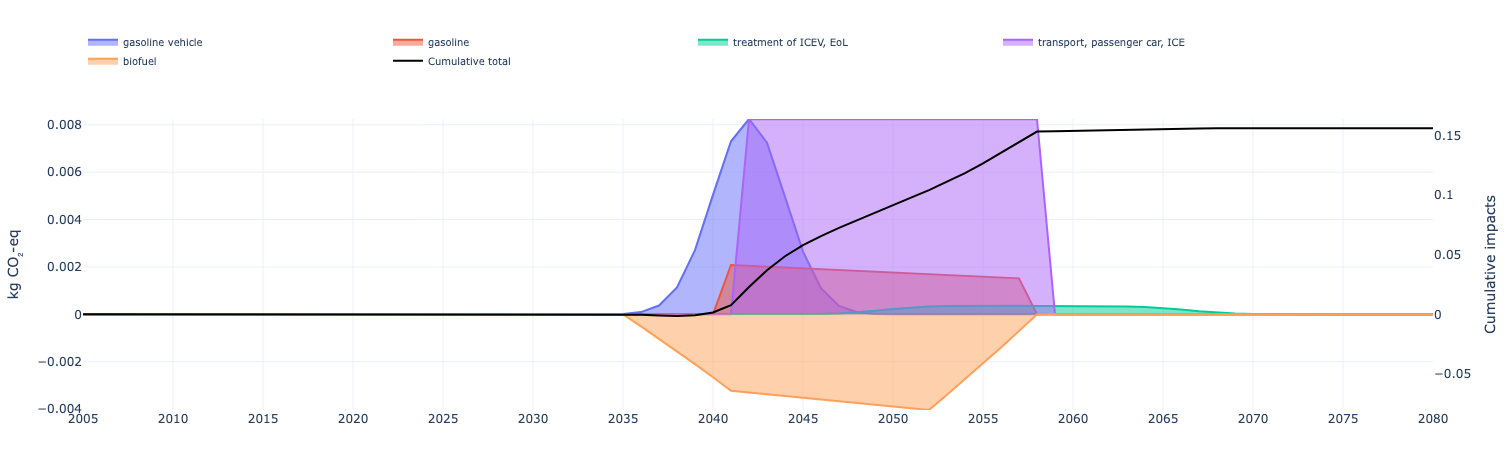

In [12]:
fig = plot_temporal_scores(
    stacked=False,
    legend_top_n=5,
    show_flow_contributions=False,
    trails=trails,
    title="",
    method_label="kg CO₂-eq",
    cumulative=False,
    width=550,
    height=450,
    year_tick=5,
    year_range=(2005, 2080),
    show_cumulative_axis=True,
    cumulative_axis_label="Cumulative impacts",
    legend_y=1.15,
    static_score=trails.static_score,
    static_score_dash= "dot",
    static_score_color= "red",
    #y_max=0.001,
    #y2_max=0.005
)
fig.show()

In [3]:
from trails.fair_rf import run_fair_delta_rf

rf = run_fair_delta_rf(
  trails,
  scenario="high-extension"
)

/opt/homebrew/Caskroom/miniforge/base/envs/trails/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Running 1 projections in parallel: 100%|█| 750/750 [00:00<00:00, 7000.77timestep


FAIR debug: auto scale_factor 7238501814251.867
FAIR emissions delta check failed: CO2 FFI: max_abs=1.091e+11 kg/yr max_rel=1.000e+00; CO2 AFOLU: max_abs=3.457e+10 kg/yr max_rel=1.000e+00


Running 1 projections in parallel: 100%|█| 750/750 [00:00<00:00, 7119.00timestep
Running 1 projections in parallel: 100%|█| 750/750 [00:00<00:00, 7189.48timestep
Running 1 projections in parallel: 100%|█| 750/750 [00:00<00:00, 6983.17timestep


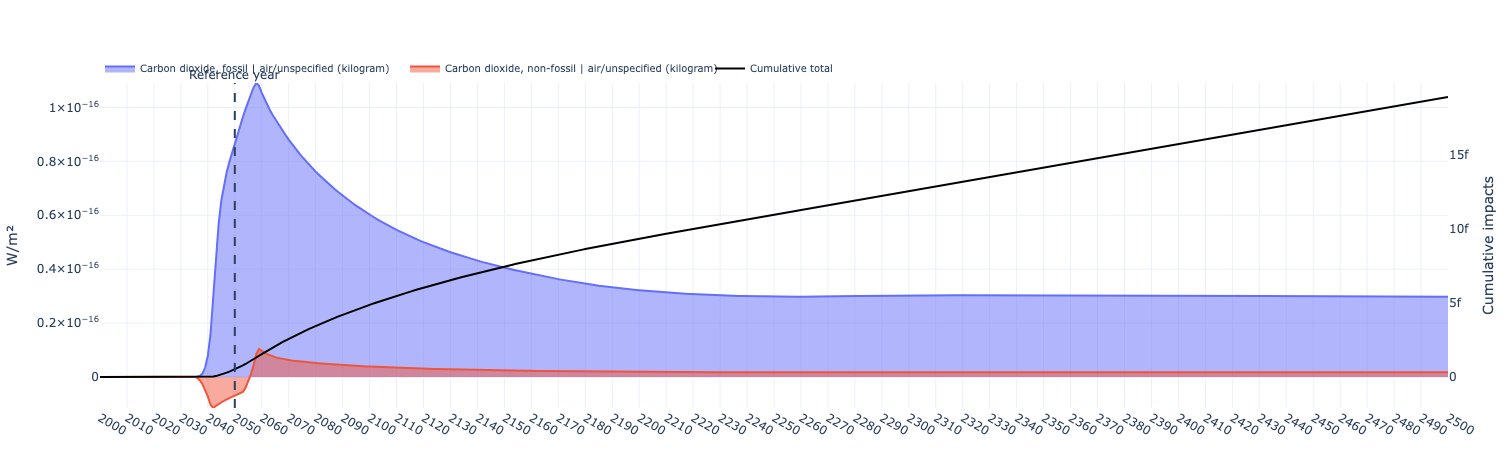

In [5]:
from trails.plotting import plot_rf

fig = plot_rf(
    trails=trails,
    reference_year=2050,
    by="flow",
    year_range=(2000, 2500),
    year_tick=10,
    #y_max=0.2e-16
)
fig.show()

In [9]:
import numpy as np
import pandas as pd

def check_non_fossil_co2_balance(
  trails,
  name="Carbon dioxide, non-fossil",
  year_range=(2030, 2060),
):
  inv = trails.inventory
  if inv is None:
      raise ValueError("trails.inventory is empty; run LCA first.")
  if "root activity" not in inv.dims:
      raise ValueError("inventory lacks 'root activity' dimension.")

  # Build flow index -> (name, compartment, subcompartment)
  flow_meta = {}
  for _, meta in getattr(trails, "biosphere_indices", {}).items():
      for fid, md in meta.items():
          if not isinstance(md, dict):
              continue
          n = md.get("name")
          if not n:
              continue
          comp = (md.get("compartment") or "").strip()
          sub = (md.get("subcompartment") or "").strip()
          flow_meta[int(fid)] = (str(n), comp, sub)

  # Find matching flow indices
  flow_idx = [fid for fid, (n, _, _) in flow_meta.items() if n == name]
  if not flow_idx:
      print(f"No flows found for name '{name}'")
      return

  # inventory uses flow coordinates as indices; map to positions
  flow_coord = inv.coords["flow"].values
  pos_by_flow = {int(v): i for i, v in enumerate(flow_coord)}

  positions = [pos_by_flow[fid] for fid in flow_idx if fid in pos_by_flow]
  if not positions:
      print(f"No flow positions found for '{name}' in inventory coordinates")
      return

  # Sum over activity dimension, keep flow/year/root
  inv_sum = inv.sum(dim=["activity"]).transpose("flow", "year", "root activity")
  data = np.asarray(
      inv_sum.data.todense() if hasattr(inv_sum.data, "todense") else inv_sum.data
  )

  # Aggregate over matching flows
  flow_slice = data[positions, :, :]  # (flow, year, root)
  by_year_root = flow_slice.sum(axis=0)  # (year, root)
  years = inv_sum.coords["year"].values.astype(int)
  roots = inv_sum.coords["root activity"].values.astype(int)

  # Filter years
  y0, y1 = year_range
  year_mask = (years >= y0) & (years <= y1)
  if not np.any(year_mask):
      print(f"No years found in range {year_range}")
      return

  by_year_root = by_year_root[year_mask, :]
  years = years[year_mask]

  # Totals per year
  total_by_year = by_year_root.sum(axis=1)
  pos_by_year = np.clip(by_year_root, 0, None).sum(axis=1)
  neg_by_year = np.clip(by_year_root, None, 0).sum(axis=1)

  # Print table
  df_year = pd.DataFrame(
      {
          "total": total_by_year,
          "positive": pos_by_year,
          "negative": neg_by_year,
      },
      index=years,
  )
  print(df_year.head(10))
  print("...")
  print(df_year.tail(10))

  # Per-root totals
  per_root = by_year_root.sum(axis=0)
  top = np.argsort(np.abs(per_root))[::-1][:10]
  print("Top roots by absolute total (root_id, total_kg):")
  for i in top:
      print(int(roots[i]), float(per_root[i]))

  return {
      "years": years,
      "roots": roots,
      "by_year_root": by_year_root,
      "total_by_year": total_by_year,
      "pos_by_year": pos_by_year,
      "neg_by_year": neg_by_year,
      "per_root": per_root,
      "flow_positions": positions,
      "flow_ids": flow_idx,
  }

# Usage:
result = check_non_fossil_co2_balance(trails, year_range=(2030, 2060))

         total  positive  negative
2030  0.000000       0.0  0.000000
2031  0.000000       0.0  0.000000
2032  0.000000       0.0  0.000000
2033  0.000000       0.0  0.000000
2034  0.000000       0.0  0.000000
2035  0.000000       0.0  0.000000
2036 -0.000506       0.0 -0.000506
2037 -0.001025       0.0 -0.001025
2038 -0.001556       0.0 -0.001556
2039 -0.002100       0.0 -0.002100
...
         total  positive  negative
2051  0.000235  0.004200 -0.003965
2052  0.000243  0.004282 -0.004039
2053  0.000968  0.004365 -0.003397
2054  0.001705  0.004447 -0.002742
2055  0.002454  0.004529 -0.002075
2056  0.003216  0.004612 -0.001396
2057  0.003990  0.004694 -0.000704
2058  0.004776  0.004776  0.000000
2059  0.000000  0.000000  0.000000
2060  0.000000  0.000000  0.000000
Top roots by absolute total (root_id, total_kg):
13 0.07000000029802322
16 -0.061740003526210785
7 0.0
1 0.0
2 0.0
3 0.0
4 0.0
5 0.0
6 0.0
8 0.0


In [4]:
from trails.fair_rf import run_fair_delta_rf

rf = run_fair_delta_rf(
  trails,
  scenario="high-extension",  # from REMIND file
    scale_factor=1e25
)

Running 1 projections in parallel: 100%|█| 750/750 [00:00<00:00, 7164.17timestep
Running 1 projections in parallel: 100%|█| 750/750 [00:00<00:00, 7131.92timestep

FAIR debug: delta forcing CO2 max 9.642509248467844e-24
FAIR debug: delta forcing max 9.642509248467844e-24


In [9]:
for s in [1, 1e3, 1e6, 1e9, 1e12, 1e13, 1e14, 1e15, 1e16]:
    print("scale_factor", s)
    rf = run_fair_delta_rf(
      trails,
      scenario="REMIND | SSP1-NPi2025", 
      scale_factor=s
    )
    print(s, float(rf.sum()))

scale_factor 1


Running 1 projections in parallel: 100%|█| 750/750 [00:00<00:00, 6858.59timestep
Running 1 projections in parallel: 100%|█| 750/750 [00:00<00:00, 6751.76timestep


FAIR debug: delta forcing CO2 max 1.1102230246251565e-15
FAIR debug: delta forcing max 1.1102230246251565e-15
1 6.050715484207103e-15
scale_factor 1000.0


Running 1 projections in parallel: 100%|█| 750/750 [00:00<00:00, 6820.48timestep
Running 1 projections in parallel: 100%|█| 750/750 [00:00<00:00, 6927.12timestep


FAIR debug: delta forcing CO2 max 2.2609691896491315e-16
FAIR debug: delta forcing max 2.2609691896491315e-16
1000.0 5.641598299632733e-15
scale_factor 1000000.0


...

FAIR debug: delta forcing CO2 max 2.262198400522181e-16
FAIR debug: delta forcing max 2.262198400522181e-16
100000000000000.0 5.6252062479796e-15
scale_factor 1000000000000000.0


Running 1 projections in parallel: 100%|█| 750/750 [00:00<00:00, 6953.79timestep
Running 1 projections in parallel: 100%|█| 750/750 [00:00<00:00, 7037.23timestep


FAIR debug: delta forcing CO2 max 2.2174238026018917e-16
FAIR debug: delta forcing max 2.2174238026018917e-16
1000000000000000.0 5.534085314550476e-15
scale_factor 1e+16


Running 1 projections in parallel: 100%|█| 750/750 [00:00<00:00, 7053.72timestep
Running 1 projections in parallel: 100%|█| 750/750 [00:00<00:00, 6802.49timestep

FAIR debug: delta forcing CO2 max 1.869783427460689e-16
FAIR debug: delta forcing max 1.869783427460689e-16
1e+16 4.8016057893733844e-15


In [10]:
rf.sum()

<xarray.DataArray ()> Size: 8B
array(4.80160579e-15)

In [4]:
rf.sum()

<xarray.DataArray ()> Size: 8B
array(3.36857665e-22)

In [11]:
from trails.fair_rf import load_emissions_csv, load_species_mapping, _inventory_emissions_by_fair_species, _convert_kg_to_unit
import numpy as np

scenario = "REMIND | SSP1-NPi2025"
df = load_emissions_csv()
df = df[(df["scenario"] == scenario) & (df["region"].str.lower()== "world")].copy()

species_map, signs = load_species_mapping()
delta = _inventory_emissions_by_fair_species(trails, species_map, signs)

print("delta species:", list(delta.columns))
print("delta total (kg):", float(np.abs(delta.values).sum()))

# Pick a species that exists in both delta and df
specie = delta.columns[0]
row = df[df["variable"] == specie].iloc[0]
years = [c for c in df.columns if c.isdigit()]
print("species", specie, "unit", row["unit"])
print("before sum:", float(row[years].sum()))

# Apply one delta year to see effect
yr = int(delta.index[0])
before = row[str(yr)]
add = _convert_kg_to_unit(np.array([delta.loc[yr, specie]]), row["unit"])[0]
print("example year", yr, "before", before, "add", add, "after", before + add)

delta species: ['CO2 FFI', 'CO2 AFOLU']
delta total (kg): 0.17838606238365173
species CO2 FFI unit Mt CO2/yr
before sum: 2707746.127751724
example year 1997 before 24.39633634 add 0.0 after 24.39633634


In [5]:
import numpy as np

print("inventory nnz:", trails.inventory.data.nnz if hasattr(trails.inventory.data, "nnz") else "dense")
print("inventory abs sum:", float(np.abs(trails.inventory).sum()))

from trails.fair_rf import load_species_mapping, _inventory_emissions_by_fair_species
species_map, signs = load_species_mapping()
print("mapped species:", sorted(set(species_map.values()))[:10], "…", len(set(species_map.values())))

delta = _inventory_emissions_by_fair_species(trails,
species_map, signs)
print("delta species cols:", list(delta.columns))
print("delta abs sum:", float(np.abs(delta.values).sum()))



inventory nnz: 322
inventory abs sum: 0.27972960472106934
mapped species: ['C2F6', 'CF4', 'CH4', 'CO', 'CO2 AFOLU', 'CO2 FFI', 'HFC-125', 'HFC-134a', 'HFC-23', 'HFC-32'] … 14
delta species cols: ['CO2 FFI', 'CO2 AFOLU']
delta abs sum: 0.17838606238365173


In [6]:
from trails.fair_rf import run_fair_delta_rf, load_emissions_csv
from trails.fair_rf import _run_fair_emissions

df = load_emissions_csv()
scenario = "REMIND | SSP1-NPi2025"

f_base = _run_fair_emissions(df, scenario)
f_pert = _run_fair_emissions(df, scenario)

print("forcing dims:", f_base.forcing.dims)
print("forcing species (first 10):",
f_base.forcing.coords["specie"].values[:10])

# show baseline forcing totals
base_sum = f_base.forcing.sum().values
pert_sum = f_pert.forcing.sum().values
print("base sum:", float(base_sum), "pert sum:",
float(pert_sum))

# extract CO2 components if present
for s in ["CO2", "CO2 FFI", "CO2 AFOLU"]:
  if s in f_base.forcing.coords["specie"].values:
      arr = f_base.forcing.sel(specie=s)
      print(s, "base sum", float(arr.sum().values))

Running 1 projections in parallel: 100%|█| 750/750 [00:00<00:00, 6481.16timestep
Running 1 projections in parallel: 100%|█| 750/750 [00:00<00:00, 6626.38timestep

forcing dims: ('timebounds', 'scenario', 'config', 'specie')
forcing species (first 10): ['BC' 'C2F6' 'C3F8' 'C4F10' 'C5F12' 'C6F14' 'C7F16' 'C8F18' 'CCl4' 'CF4']
base sum: 0.0 pert sum: 0.0
CO2 base sum 0.0
CO2 FFI base sum 0.0
CO2 AFOLU base sum 0.0


In [7]:
# total emissions in FaIR
print("emissions sum:", float(f_base.emissions.sum().values))

# check a couple of species
for s in ["CO2 FFI", "CO2 AFOLU", "CH4", "N2O"]:
  if s in f_base.emissions.coords["specie"].values:
      v = f_base.emissions.sel(specie=s).sum().values
      print(s, "emissions sum:", float(v))

emissions sum: 4409650.0654706005
CO2 FFI emissions sum: 2704.587721035995
CO2 AFOLU emissions sum: -424.427582832088
CH4 emissions sum: 109322.4740362
N2O emissions sum: 1180.1411446025065


In [8]:
import numpy as np

print("forcing max abs:", float(np.abs(f_base.forcing).max()))
print("concentration max abs:",
float(np.abs(f_base.concentration).max()))
print("temperature max abs:",
float(np.abs(f_base.temperature).max()))

# check a single species time series
for s in ["CH4", "N2O", "CO2 FFI", "CO2 AFOLU"]:
  if s in f_base.forcing.coords["specie"].values:
      arr = f_base.forcing.sel(specie=s)
      print(s, "forcing max:", float(np.abs(arr).max()))

forcing max abs: nan
concentration max abs: 1812.372359130393
temperature max abs: nan
CH4 forcing max: nan
N2O forcing max: nan
CO2 FFI forcing max: nan
CO2 AFOLU forcing max: nan


In [10]:
import numpy as np

print("emissions NaNs:", int(np.isnan(f_base.emissions).sum()))
print("concentration NaNs:",
int(np.isnan(f_base.concentration).sum()))
print("forcing NaNs:", int(np.isnan(f_base.forcing).sum()))

for s in ["CO2", "CO2 FFI", "CO2 AFOLU", "CH4", "N2O"]:
  if s in f_base.concentration.coords["specie"].values:
      n = int(np.isnan(f_base.concentration.sel(specie=s)).sum())
      print(s, "concentration NaNs:", n)

emissions NaNs: 0
concentration NaNs: 6802
forcing NaNs: 39052
CO2 concentration NaNs: 1
CO2 FFI concentration NaNs: 751
CO2 AFOLU concentration NaNs: 751
CH4 concentration NaNs: 1
N2O concentration NaNs: 1


In [6]:
trails.instant_radiative_forcing.sum()

<xarray.DataArray ()> Size: 8B
array(0.)

In [5]:
trails.instant_radiative_forcing.shape

(2, 96, 17)

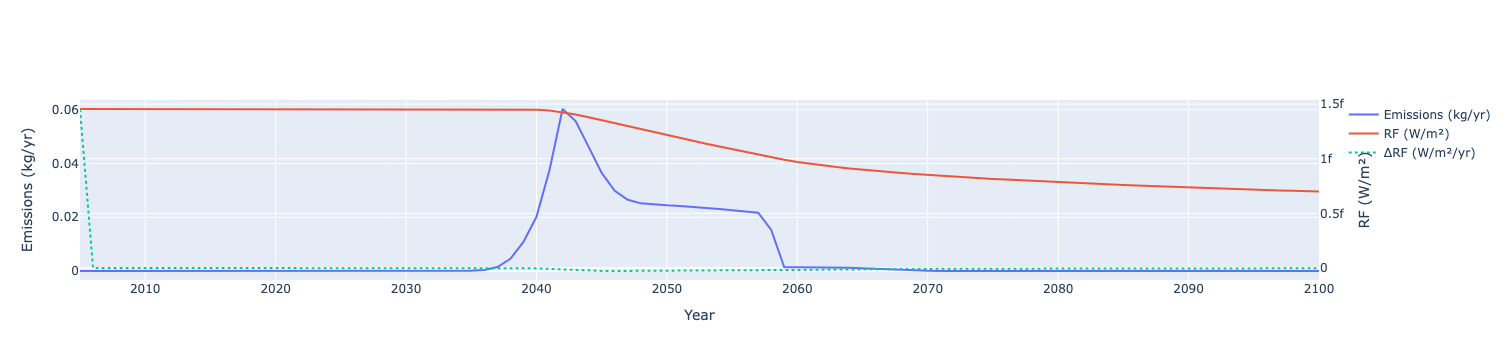

In [24]:
import numpy as np
import plotly.graph_objects as go

def dense1d(x):
  arr = x.data
  v = np.asarray(arr.todense()) if hasattr(arr, "todense") else np.asarray(x.values)
  return v.ravel()

years = emissions["year"].values

# Ensure 1D
if "root activity" in emissions.dims:
  emissions_1d = emissions.sum(dim="root activity")
else:
  emissions_1d = emissions

if "root activity" in rf.dims:
  rf_1d = rf.sum(dim="root activity")
else:
  rf_1d = rf

E = dense1d(emissions_1d)
R = dense1d(rf_1d)
dR = np.diff(R, prepend=0)

fig = go.Figure()
fig.add_scatter(x=years, y=E, name="Emissions (kg/yr)",
yaxis="y1")
fig.add_scatter(x=years, y=R, name="RF (W/m²)", yaxis="y2")
fig.add_scatter(x=years, y=dR, name="ΔRF (W/m²/yr)", yaxis="y2",
line=dict(dash="dot"))
fig.update_layout(
  xaxis_title="Year",
  yaxis=dict(title="Emissions (kg/yr)"),
  yaxis2=dict(title="RF (W/m²)", overlaying="y", side="right"),
)
fig.show()

In [21]:
# emissions time series (sum over activity/root, per flow)
inv = trails.inventory
if "root activity" in inv.dims:
  inv_sum = inv.sum(dim=["activity", "root activity"])
else:
  inv_sum = inv.sum(dim=["activity"])

# pick a gas flow, e.g. CO2 fossil
flow_ids = [fid for _lbl, meta in
trails.biosphere_indices.items()
          for fid, md in meta.items()
          if md.get("name") == "Carbon dioxide, fossil"]

import numpy as np
def _dense(x):
  arr = x.data
  return np.asarray(arr.todense()) if hasattr(arr, "todense") else np.asarray(x.values)

emissions = inv_sum.sel(flow=flow_ids).sum(dim="flow")
rf = trails.instant_radiative_forcing.sel(flow=flow_ids).sum(dim="flow")

print("emissions:", _dense(emissions).ravel())
print("rf:", _dense(rf).ravel())

emissions: [0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 1.1420379e-05
 7.4179334e-05 3.7523644e-04 1.4782459e-03 4.5353207e-03 1.0836496e-02
 2.0164581e-02 3.7555311e-02 6.0277972e-02 5.5815455e-02 4.6203014e-02
 3.6481444e-02 2.9866077e-02 2.6522363e-02 2.5171705e-02 2.4676245e-02
 2.4440087e-02 2.4214728e-02 2.3915594e-02 2.3531770e-02 2.3091706e-02
 2.2624740e-02 2.2148184e-02 2.1669045e-02 1.5256412e-02 1.4118678e-03
 1.4021005e-03 1.3898610e-03 1.3685959e-03 1.3224167e-03 1.2251392e-03
 1.0527453e-03 8.0836879e-04 5.3583790e-04 2.9812311e-04 1.3631776e-04
 5.0456161e-05 1.4952621e-05 3.5157898e-06 6.4608230e-07 8.5293159

In [2]:
trails.print_exchange_table(year=2050, act_idx=13, max_rows=50)

flow type    | id           | name                           | reference product             | amount       | td type      | loc          | scale        | min          | max         
-------------+--------------+--------------------------------+-------------------------------+--------------+--------------+--------------+--------------+--------------+-------------
prod         | 13           | transport, passenger car, ICEV | transport, passenger car, ICE | 1.00         |              |              |              |              |             
bio          | 0            | Carbon dioxide, fossil         |                               | 0.07         | 4            | 0.0          |              | -8           | 8           
bio          | 1            | Carbon dioxide, non-fossil     |                               | 0.07         | 4            | 0.0          |              | -8           | 8           
tech         | 11           | gasoline production            | gasoline              

In [3]:
trails.temporal_routing(
  start_year=2050,
  start_act_idx=13,
  amount=1.0,
  max_depth=2,
  show_progress=True,
  attribute_to_roots=True,
)

Temporal routing: 392node [00:00, 26391.97node/s]


In [4]:
from trails.plotting import plot_temporal_graph

plot_temporal_graph(
    trails,
)

'trails_graph.html'

In [5]:
trails.lca(
    methods=methods,
    show_progress=True,
)

Temporal LCA: solve years: 100%|█████████████| 41/41 [00:00<00:00, 613.72year/s]


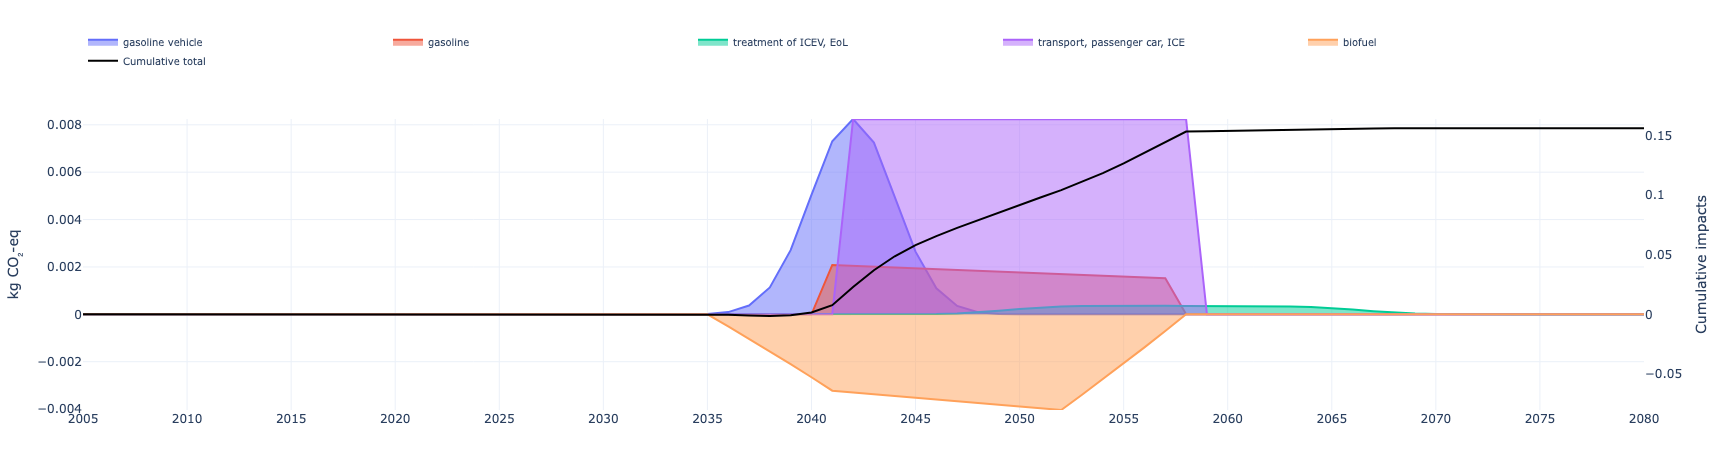

In [9]:
fig = plot_temporal_scores(
    trails.scores,
    stacked=False,
    legend_top_n=5,
    show_flow_contributions=False,
    trails=trails,
    title="",
    method_label="kg CO₂-eq",
    cumulative=False,
    width=550,
    height=450,
    year_tick=5,
    year_range=(2005, 2080),
    show_cumulative_axis=True,
    cumulative_axis_label="Cumulative impacts",
    legend_y=1.15,
    static_score=trails.static_score,
    static_score_dash= "dot",
    static_score_color= "red",
    #y_max=0.001,
    #y2_max=0.005
)
fig.show()

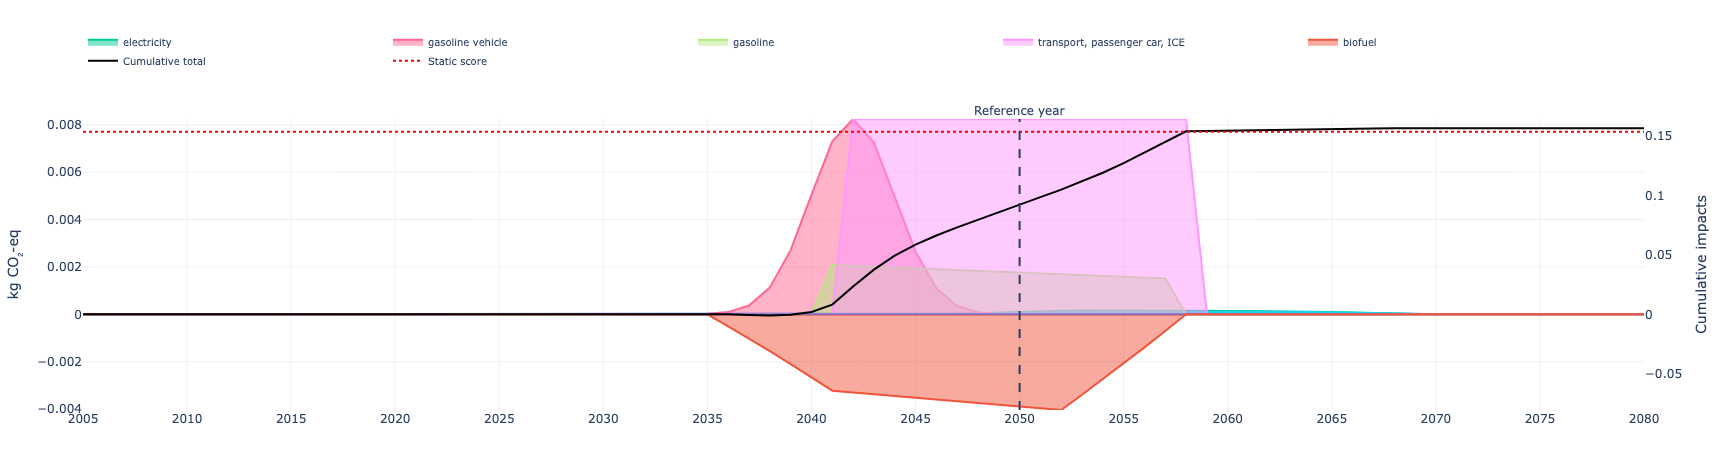

In [4]:
fig = plot_temporal_scores(
    results_by_year=trails.characterized_inventory,
    stacked=False,
    legend_top_n=5,
    show_flow_contributions=False,
    trails=trails,
    title="",
    method_label="kg CO₂-eq",
    cumulative=False,
    width=550,
    height=450,
    year_tick=5,
    year_range=(2005, 2080),
    reference_year=ref_year,
    show_cumulative_axis=True,
    cumulative_axis_label="Cumulative impacts",
    legend_y=1.15,
    static_score=trails.static_score,
    static_score_dash= "dot",
    static_score_color= "red",
    #y_max=0.001,
    #y2_max=0.005
)
fig.show()

In [7]:
ref_year = 2050

trails.lca(
    start_year=ref_year,
    start_act_idx=2,
    methods=methods,
    max_depth=6,
    return_provenance=True,
    show_progress=True,
    min_amount=1e-18,
    debug=True
)

Temporal LCA: solve years: 100%|█████████████| 61/61 [00:00<00:00, 602.34year/s]


In [8]:
ref_year = 2050
trails.static_lca(
    year=ref_year,
    act_idx=2,
    methods=methods,
)

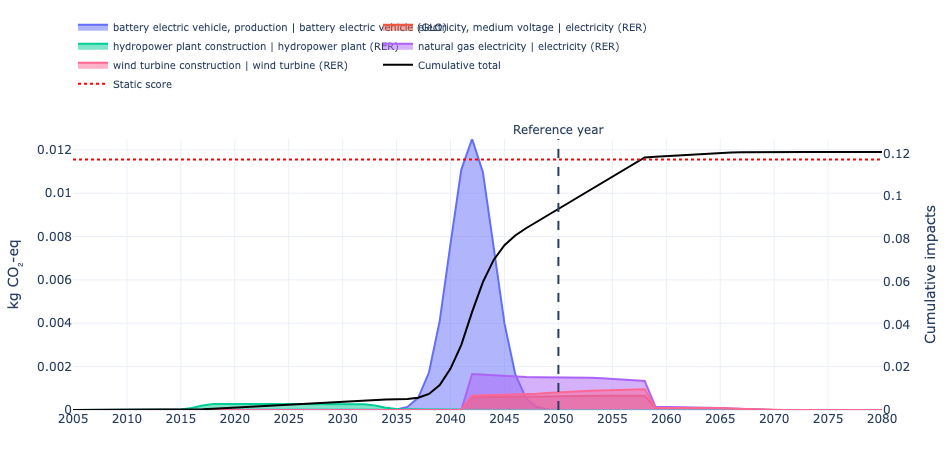

In [9]:
fig = plot_temporal_scores(
    results_by_year=trails.characterized_inventory,
    stacked=False,
    legend_top_n=5,
    show_flow_contributions=False,
    trails=trails,
    title="",
    method_label="kg CO₂-eq",
    cumulative=False,
    width=550,
    height=450,
    year_tick=5,
    year_range=(2005, 2080),
    reference_year=ref_year,
    show_cumulative_axis=True,
    cumulative_axis_label="Cumulative impacts",
    legend_y=1.15,
    static_score=trails.static_score,
    static_score_dash= "dot",
    static_score_color= "red",
    #y_max=0.001,
    #y2_max=0.005
)
fig.show()

In [9]:
from trails.plotting import plot_traversal_grid_flow
edges_by_depth = trails.collect_traversal_edges(
    start_year=2050,
    start_act_idx=13,
    amount=1.0,
    max_depth=5,
    min_amount=1e-18,
)

fig = plot_traversal_grid_flow(
    edges_by_depth=edges_by_depth,
    trails=trails,
    depths=None,                 
    include_all_activities=True,
    title="Traversal flows by depth",
    dot_size=5,
)

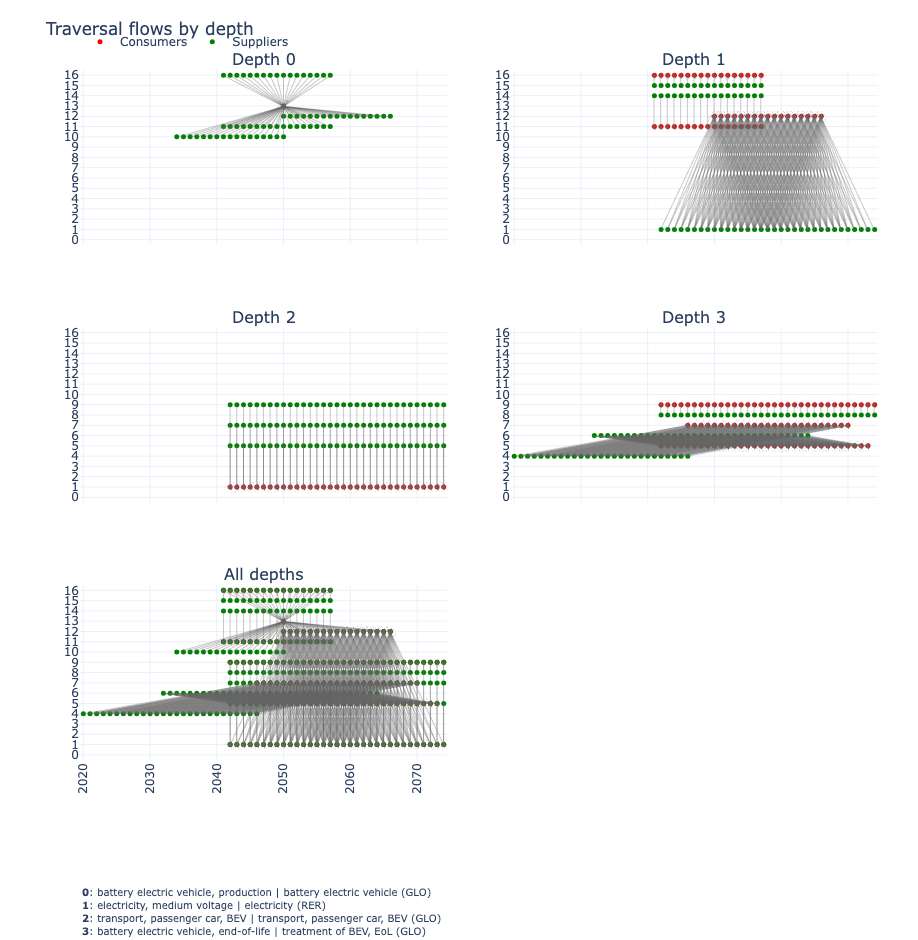

In [10]:
fig